In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

X0 = np.random.multivariate_normal([0,0], [[1,0],[0,1]], 500)
X1 = np.random.multivariate_normal([3,3], [[1,0],[0,1]], 500)

X = np.vstack((X0, X1))
y = np.array([0]*50 + [1]*50)

mu0=np.mean(X0,axis=0)
mu1=np.mean(X1,axis=0)
def compute_shared_cov(X0, X1):
    N0 = X0.shape[0]
    N1 = X1.shape[0]
    X0_centered = X0 - mu0
    X1_centered = X1 - mu1
    cov = (X0_centered.T @ X0_centered + X1_centered.T @ X1_centered) / (N0 + N1 - 2)
    return cov

cov_shared = compute_shared_cov(X0, X1)

print(cov_shared)
# def prior_p(X):

    



[[ 0.94942189 -0.01401394]
 [-0.01401394  0.96550331]]


0.5 0.5


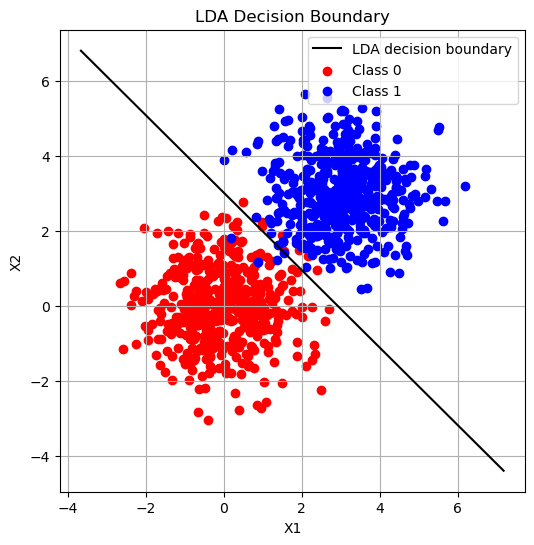

In [17]:
def prior_p(X,y):
    classes=np.unique(y)
    sample_n=len(y)

    prior={}
    for cls in classes:
        counter=0
        for s in y:
            if s==cls: counter+=1
        prior[int(cls)]=float(counter/sample_n)
    
    return prior
prior=prior_p(X,y)
P0=prior[0]
P1=prior[1]
print(P0,P1)

##LDA
Sigma_inv = np.linalg.inv(cov_shared)
w = Sigma_inv @ (mu1 - mu0)
c = 0.5 * (mu1.T @ Sigma_inv @ mu1 - mu0.T @ Sigma_inv @ mu0)  # P0=P1, ln(P1/P0)=0

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx = np.linspace(x_min, x_max, 200)
yy = (-w[0]*xx + c) / w[1]  # w0*x + w1*y = c -> y = (-w0*x+c)/w1


plt.figure(figsize=(6,6))
plt.plot(xx, yy, 'k-', label='LDA decision boundary')
plt.scatter(X0[:,0], X0[:,1], color='red', label='Class 0')
plt.scatter(X1[:,0], X1[:,1], color='blue', label='Class 1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('LDA Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()
